# RQ1 — Saturation of the configuration space

How much of a program's documented option space actually gets used?

Three panels, left to right:

- **(a)** how much of the space is ever touched — most options are never used, and each cohort's reach is marked in the unused track.
- **(b)** how deep a typical call goes — most invocations pass no option at all.
- **(c)** how concentrated the usage is — Lorenz curves labelled with Gini (G) and normalised Shannon entropy (H).

Output: `results/analysis/figures/rq1_saturation.pdf`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# find the results dir by walking up from the notebook
BASE = Path.cwd()
while not (BASE / 'results' / 'analysis').exists() and BASE != BASE.parent:
    BASE = BASE.parent
AN  = BASE / 'results' / 'analysis'
FIG = AN / 'figures'; FIG.mkdir(exist_ok=True)
def load(name): return pd.read_csv(AN / name)

# plot style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12.5,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 12, 'axes.labelcolor': '#222222',
    'axes.edgecolor': '#9aa0a6', 'axes.linewidth': 0.9,
    'xtick.color': '#3c4043', 'ytick.color': '#3c4043',
    'xtick.labelsize': 11.5, 'ytick.labelsize': 11.5,
    'text.color': '#202124',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130, 'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})

# Okabe-Ito colours
C     = {'human': '#0072B2', 'llm': '#D55E00', 'kernel': '#009E73'}
USED  = '#2f7df6'   # used slice in (a)
TRACK = '#eef1f5'   # unused remainder
DS   = ['gnu', 'git', 'ci']
DSL  = {'gnu': 'GNU utilities', 'git': 'Git', 'ci': 'CI tooling'}
print('results dir:', AN)

results dir: /home/ternava/Documents/GitHub/llms-miss/results/analysis


In [2]:
# load the summary tables
summ = load('a1_dataset_summary.csv').set_index('dataset')   # never-used share
dist = load('a7_distribution.csv')                           # zero-option share
cov  = load('a1_population_coverage.csv')                     # reach per cohort
conc = load('a7_concentration.csv')                          # Gini + Shannon entropy
inv  = load('invocations_long.csv')
gt   = load('groundtruth_long.csv')

# count uses over the valid (unit, option) pairs each cohort actually used
used   = inv[inv.option.notna() & (inv.option != '')].merge(gt, on=['dataset', 'unit', 'option'])
counts = used.groupby(['dataset', 'population', 'unit', 'option']).size().reset_index(name='uses')

# metric lookups keyed by (dataset, cohort)
reach = {(r.dataset, r.population): r.reach_pct for r in cov.itertuples()}
ent   = {(r.dataset, r.population): r.norm_entropy for r in conc.itertuples()}

def lorenz(c):
    """x: cumulative share of used options (most used first); y: cumulative share of uses."""
    c = np.sort(np.asarray(c, float))[::-1]
    y = np.concatenate([[0], np.cumsum(c) / c.sum()])
    return np.linspace(0, 1, len(y)) * 100, y * 100

def gini(c):
    c = np.sort(np.asarray(c, float)); n = len(c)
    return (2 * np.sum(np.arange(1, n + 1) * c) / (n * c.sum())) - (n + 1) / n

def metric(table, d, p, col):
    return table[(table.dataset == d) & (table.population == p)].iloc[0][col]

## The figure

One row, three panels: saturation, then shallowness, then concentration.

wrote /home/ternava/Documents/GitHub/llms-miss/results/analysis/figures/rq1_saturation.pdf


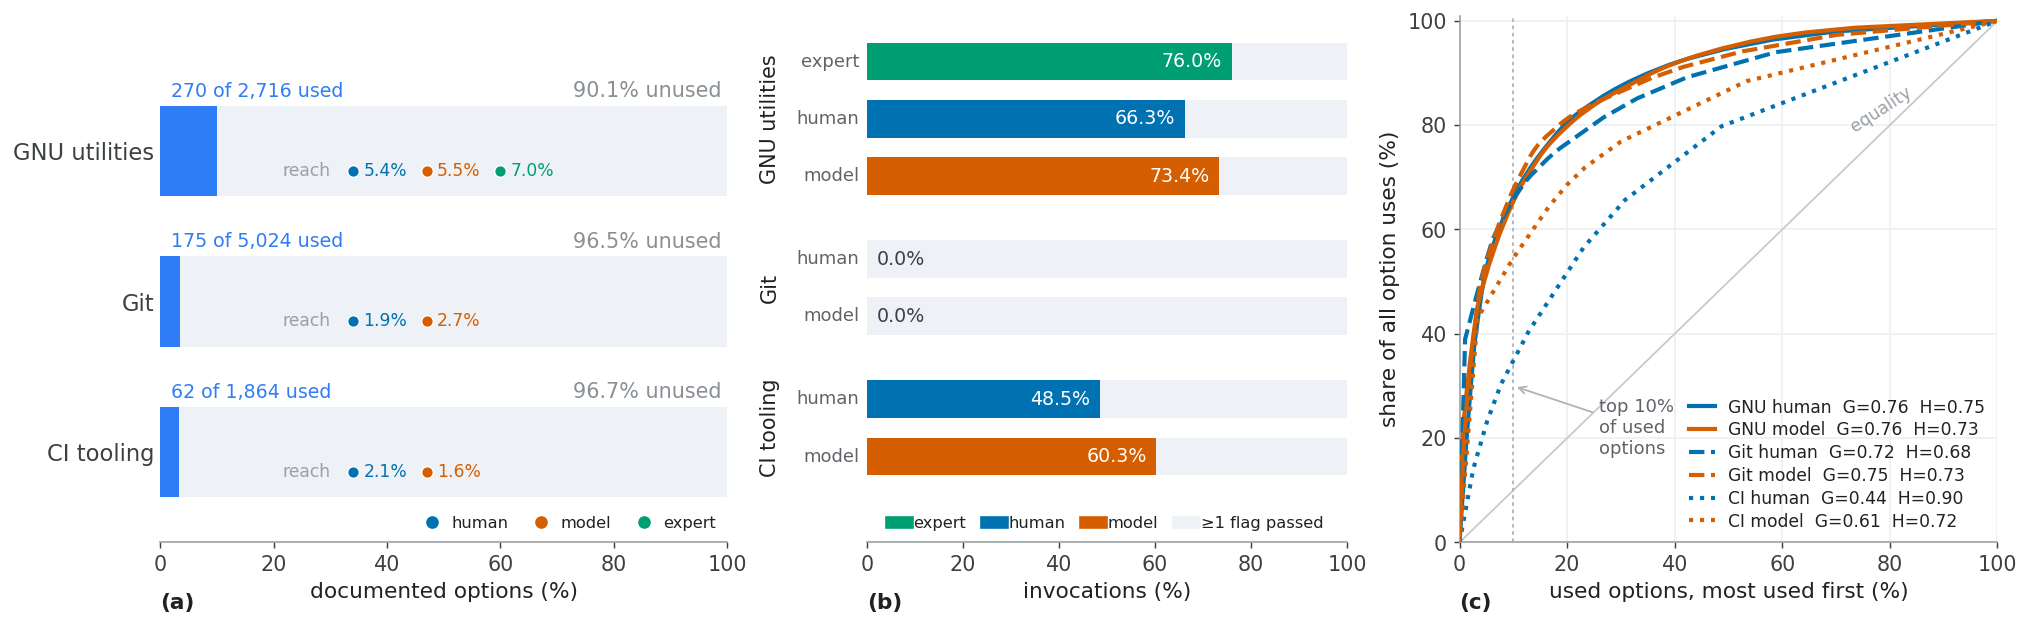

In [3]:
fig, (axA, axB, axC) = plt.subplots(
    1, 3, figsize=(15.5, 4.7),
    gridspec_kw={'width_ratios': [1.18, 1.0, 1.12]})
fig.set_constrained_layout(True)

# (a) saturation + per-cohort reach
reachOrder = {'gnu': ['human', 'llm', 'kernel'], 'git': ['human', 'llm'], 'ci': ['human', 'llm']}
LAB = {'kernel': 'expert', 'human': 'human', 'llm': 'model'}
y = np.arange(len(DS))[::-1]
for yi, d in zip(y, DS):
    used_pct = 100 - summ.loc[d, 'never_pct']
    n_used = int(summ.loc[d, 'opts_union']); n_tot = int(summ.loc[d, 'gt_options'])
    axA.barh(yi, 100, color=TRACK, edgecolor='none', height=0.60, zorder=1)        # whole space
    axA.barh(yi, used_pct, color=USED, edgecolor='none', height=0.60, zorder=2)    # used sliver
    axA.text(99, yi + 0.40, f"{summ.loc[d, 'never_pct']:.1f}% unused",
             ha='right', va='center', fontsize=11.5, color='#8a8f94', zorder=3)
    axA.text(1.8, yi + 0.40, f"{n_used} of {n_tot:,} used",
             ha='left', va='center', fontsize=10.5, color=USED, zorder=3)
    # reach dots in the unused track
    axA.text(30, yi - 0.13, 'reach', ha='right', va='center', fontsize=9.5, color='#9aa0a6')
    xx = 34
    for p in reachOrder[d]:
        axA.scatter(xx, yi - 0.13, s=42, color=C[p], edgecolor='white', linewidth=0.8, zorder=3)
        axA.text(xx + 1.8, yi - 0.13, f"{reach[(d, p)]:.1f}%", ha='left', va='center',
                 fontsize=9.5, color=C[p], zorder=3)
        xx += 13
axA.set_yticks(y); axA.set_yticklabels([DSL[d] for d in DS], fontsize=12.5)
axA.set_xlim(0, 100); axA.set_xlabel('documented options (%)')
axA.set_ylim(-0.6, len(DS) - 0.1)
axA.text(0.0, -0.115, '(a)', transform=axA.transAxes, fontsize=12, fontweight='bold', va='center', ha='left')
axA.tick_params(axis='y', length=0); axA.spines['left'].set_visible(False)
axA.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=C[k],
                           markeredgecolor='white', markersize=8, label=LAB[k])
                    for k in ('human', 'llm', 'kernel')],
           frameon=False, fontsize=9, loc='lower right', ncol=3,
           handletextpad=0.2, columnspacing=1.0, borderpad=0.2)

# (b) shallowness: no-option vs >=1 option
orderB = {'gnu': ['kernel', 'human', 'llm'], 'git': ['human', 'llm'], 'ci': ['human', 'llm']}
rows = [(d, p, dist[(dist.dataset == d) & (dist.population == p)].iloc[0]['pct_zero_option'])
        for d in DS for p in orderB[d]]
ypos, ylab, group_centers = [], [], {}
yy = 0
for d in DS:
    start = yy
    for p in orderB[d]:
        ypos.append(yy); ylab.append(LAB[p]); yy += 1
    group_centers[d] = (start + yy - 1) / 2; yy += 0.45
ypos = np.array(ypos)
for (d, p, z), yi, lab in zip(rows, ypos, ylab):
    axB.barh(yi, z, height=0.66, color=C[p], edgecolor='none', zorder=2)                 # no option
    axB.barh(yi, 100 - z, left=z, height=0.66, color=TRACK, edgecolor='none', zorder=1)  # >=1 option
    axB.text(z - 2 if z > 14 else z + 2, yi, f"{z:.1f}%", va='center',
             ha='right' if z > 14 else 'left', fontsize=10.5,
             color='white' if z > 14 else '#3c4043', zorder=3)
    axB.text(-1.5, yi, lab, va='center', ha='right', fontsize=10, color='#5f6368', zorder=3)
for d in DS:
    axB.text(-18, group_centers[d], DSL[d], va='center', ha='right',
             fontsize=11.5, color='#202124', rotation=90)
axB.set_yticks([]); axB.set_ylim(ypos.min() - 0.8, ypos.max() + 1.5); axB.invert_yaxis()
axB.set_xlim(0, 100); axB.set_xlabel('invocations (%)')
axB.text(0.0, -0.115, '(b)', transform=axB.transAxes, fontsize=12, fontweight='bold', va='center', ha='left')
axB.spines['left'].set_visible(False); axB.tick_params(axis='y', length=0)
axB.legend(handles=[Line2D([0], [0], color=C['kernel'], lw=7, label='expert'),
                    Line2D([0], [0], color=C['human'], lw=7, label='human'),
                    Line2D([0], [0], color=C['llm'], lw=7, label='model'),
                    Line2D([0], [0], color=TRACK, lw=7, label='\u22651 flag passed')],
           frameon=False, fontsize=9, loc='lower center', ncol=4,
           handlelength=1.0, handletextpad=0.4, columnspacing=1.2,
           borderpad=0.2)

# (c) concentration: Lorenz curves with Gini & Shannon
LSTY  = {'gnu': '-', 'git': '--', 'ci': ':'}
SHORT = {'gnu': 'GNU', 'git': 'Git', 'ci': 'CI'}
axC.plot([0, 100], [0, 100], color='#c7cacd', lw=1, zorder=1)
axC.text(72, 78, 'equality', rotation=33, color='#9aa0a6', fontsize=9.5, va='bottom')
for d in DS:
    for p in ('human', 'llm'):
        c = counts[(counts.dataset == d) & (counts.population == p)]['uses']
        x, yv = lorenz(c); gi = gini(c); h = ent[(d, p)]
        axC.plot(x, yv, LSTY[d], color=C[p], lw=2.3, zorder=3,
                 label=f"{SHORT[d]} {'human' if p == 'human' else 'model'}  G={gi:.2f}  H={h:.2f}")
axC.axvline(10, color='#b0b3b8', lw=1, ls=(0, (2, 2)), zorder=2)
axC.annotate('top 10% \nof used\noptions', xy=(10, 30), xytext=(26, 17),
             fontsize=10, color='#5f6368', ha='left',
             arrowprops=dict(arrowstyle='->', color='#b0b3b8', lw=1))
axC.set_xlim(0, 100); axC.set_ylim(0, 101)
axC.set_xlabel('used options, most used first (%)')
axC.set_ylabel('share of all option uses (%)')
axC.text(0.0, -0.115, '(c)', transform=axC.transAxes, fontsize=12, fontweight='bold', va='center', ha='left')
axC.legend(frameon=False, fontsize=9.5, loc='lower right', handlelength=1.5,
           labelspacing=0.28, borderpad=0.2)
axC.grid(color='#eef0f1', lw=1, zorder=0); axC.set_axisbelow(True)

fig.savefig(FIG / 'rq1_saturation.pdf')
print('wrote', FIG / 'rq1_saturation.pdf')
plt.show()

In [4]:
# numbers cited in the text
for d in DS:
    print(f"{DSL[d]:14s}  never-used {summ.loc[d, 'never_pct']:5.1f}%   "
          f"({int(summ.loc[d, 'opts_union'])} of {int(summ.loc[d, 'gt_options'])} used)")
print()
for d in DS:
    for p in ('human', 'llm'):
        c = counts[(counts.dataset == d) & (counts.population == p)]['uses']
        top10 = np.sort(c.values)[::-1][:max(1, int(round(0.10 * len(c))))].sum() / c.sum() * 100
        print(f"{d:4s} {p:6s}  Gini {gini(c):.2f}   top 10% of used options = {top10:4.1f}% of uses")

GNU utilities   never-used  90.1%   (270 of 2716 used)
Git             never-used  96.5%   (175 of 5024 used)
CI tooling      never-used  96.7%   (62 of 1864 used)

gnu  human   Gini 0.76   top 10% of used options = 66.8% of uses
gnu  llm     Gini 0.76   top 10% of used options = 65.7% of uses
git  human   Gini 0.72   top 10% of used options = 66.3% of uses
git  llm     Gini 0.75   top 10% of used options = 68.2% of uses
ci   human   Gini 0.44   top 10% of used options = 35.4% of uses
ci   llm     Gini 0.61   top 10% of used options = 54.5% of uses
